# Classificação de Grãos (Dry Bean Dataset)

Este notebook apresenta o desenvolvimento e a avaliação de uma Rede Neural Artificial (MLP) para a classificação de sete tipos de feijões secos com base em seus atributos morfológicos.

Conforme as diretrizes da atividade, o modelo foi estruturado com foco em:
1. **Estabilidade:** Normalização das entradas e uso de Batch Normalization.
2. **Regularização:** Utilização de Dropout, Weight Decay (L2) e Early Stopping para mitigar o overfitting.
3. **Generalização e Desbalanceamento:** Estratificação na divisão dos dados, uso de pesos na função de custo e avaliação via F1-Score (Macro).

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

## 1. Pré-processamento e Preparação dos Dados

Existem dois problemas principais nos dados originais:
1. **Escalas Distintas:** Os atributos morfológicos (área, perímetro, etc.) possuem grandezas muito diferentes. Para garantir a estabilidade do treinamento e evitar gradientes instáveis, apliquei o `StandardScaler` (Input Normalization), centrando as features na média zero e variância 1.
2. **Desbalanceamento de Classes:** Para evitar que o modelo seja enviesado, utilizei `stratify` na divisão de treino e validação, garantindo a mesma proporção de cada classe em ambos os conjuntos.

In [18]:
# 1. Carregando os dados
df = pd.read_csv('beans_train.csv')

print("Distribuição das classes originais:")
print(df['Class'].value_counts())

# Separando features (X) e rótulos (y)
X_raw = df.drop(columns=['Class']).values
y_raw = df['Class'].values

# 2. Codificando os rótulos (String para Inteiros de 0 a 6)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

# 3. Divisão Treino (70%) / Restante (30%) - Estratificada
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

# 4. Divisão do Restante em Validação (15%) e Teste (15%) - Estratificada
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 5. Input Normalization (Padronização)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 6. Convertendo para Tensores do PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"\nFormato de Treino: {X_train_tensor.shape}")
print(f"Formato de Validação: {X_val_tensor.shape}")
print(f"Formato de Teste Final: {X_test_tensor.shape}")

Distribuição das classes originais:
Class
DERMASON    2849
SIRA        2119
SEKER       1613
HOROZ       1522
CALI        1306
BARBUNYA    1063
BOMBAY       416
Name: count, dtype: int64

Formato de Treino: torch.Size([7621, 16])
Formato de Validação: torch.Size([1633, 16])
Formato de Teste Final: torch.Size([1634, 16])


## 2. Arquitetura do Modelo, Estabilidade e Regularização

A arquitetura escolhida foi a Multilayer Perceptron - MLP, ideal para conjuntos de dados tabulares baseados em características morfométricas.

Para atender aos requisitos de **estabilidade** e **regularização**, implementei as seguintes técnicas diretamente na arquitetura e na configuração do treinamento:

1. **Combate ao Desbalanceamento (Pesos na Função de Custo):** Como a classe 'Bombay' possui apenas 416 amostras e a 'Dermason' 2849, a rede tenderia a ignorar a minoria. Por isso, os pesos foram calculados inversamente proporcionais à frequência de cada classe e passados para a `CrossEntropyLoss`.
2. **Batch Normalization (Estabilidade):** Adicionado após cada camada linear (antes da ativação) para garantir que as distribuições internas das ativações não mudem drasticamente, permitindo que os gradientes fluam de maneira estável.
3. **Inicialização He:** Como será utilizada a função de ativação não-linear ReLU, a inicialização de He previne que o sinal de saída desapareça no início do treino.
4. **Dropout (Regularização):** Aplicado nas camadas ocultas (com taxa de 30%) para quebrar a coadaptação dos neurônios, forçando representações distribuídas e prevenindo o overfitting.
5. **Weight Decay - L2 (Regularização):** Será utilizado o otimizador AdamW com decaimento de pesos (L2) ativo, punindo pesos excessivamente grandes e suavizando a fronteira de decisão.

In [19]:
# 1. Calculando pesos das classes para lidar com o desbalanceamento extremo
# A classe majoritária receberá peso menor, e a minoritária peso maior
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# 2. Definindo a Arquitetura da Rede Neural (MLP)
class BeansClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(BeansClassifier, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            nn.Linear(32, num_classes)
        )
        
        # 3. Inicialização de Pesos He para a ReLU
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

# 4. Instanciando o modelo, função de custo e otimizador
input_size = X_train_tensor.shape[1] # 16 features
num_classes = len(np.unique(y_train)) # 7 classes

model = BeansClassifier(input_size, num_classes).to(device)

# CrossEntropyLoss recebe os pesos de balanceamento das classes
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

print(model)
print("\nPesos calculados para as classes (balanceamento na função de custo):")
for name, weight in zip(label_encoder.classes_, class_weights):
    print(f"{name}: {weight:.4f}")

BeansClassifier(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=7, bias=True)
  )
)

Pesos calculados para as classes (balanceamento na função de custo):
BARBUNYA: 1.4633
BOMBAY: 3.7413
CALI: 1.1912
DERMASON: 0.5460
HOROZ: 1.0213
SEKER: 0.9643
SIRA: 0.7341


## 3. Treinamento com Early Stopping

Para treinar o modelo de forma estável e mitigar o overfitting, implementei um loop de treinamento com as seguintes características:
- **Monitoramento contínuo:** Acompanhei a função de custo (Loss) tanto no conjunto de treino quanto no de validação a cada época.
- **Early Stopping:** Se a perda de validação parar de cair por 10 épocas consecutivas (paciência), o treinamento é interrompido. Isso impede que a rede decore os dados de treino e perca a capacidade de generalização. Ao final, os pesos da melhor época são restaurados.

In [20]:
import copy

num_epochs = 150
patience = 10
best_loss = float('inf')
patience_counter = 0
best_model_weights = copy.deepcopy(model.state_dict())

# Histórico para os gráficos
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # FASE DE TREINO
    model.train() # Ativa Dropout e estatísticas de batch do BatchNorm
    running_train_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zera os gradientes
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass e otimização
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # FASE DE VALIDAÇÃO
    model.eval() # Desativa Dropout e usa médias globais no BatchNorm
    running_val_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    # EARLY STOPPING
    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict()) # Salva os melhores pesos
    else:
        patience_counter += 1
        
    # Imprime o progresso a cada 10 épocas ou se o early stopping for acionado
    if (epoch + 1) % 10 == 0 or patience_counter >= patience:
        print(f"Época [{epoch+1:03d}/{num_epochs:03d}] | Treino Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Paciência: {patience_counter}/{patience}")
        
    if patience_counter >= patience:
        print(f"\nEarly Stopping acionado na época {epoch+1}, o modelo parou de melhorar.")
        break

# Restaura os melhores pesos encontrados antes de estagnar
model.load_state_dict(best_model_weights)
print("\nTreinamento concluído. Melhores pesos restaurados.")

Época [010/150] | Treino Loss: 0.3447 | Val Loss: 0.2211 | Paciência: 1/10
Época [020/150] | Treino Loss: 0.3036 | Val Loss: 0.2165 | Paciência: 3/10
Época [030/150] | Treino Loss: 0.2677 | Val Loss: 0.1977 | Paciência: 0/10
Época [040/150] | Treino Loss: 0.2570 | Val Loss: 0.2058 | Paciência: 6/10
Época [044/150] | Treino Loss: 0.2458 | Val Loss: 0.1998 | Paciência: 10/10

Early Stopping acionado na época 44, o modelo parou de melhorar.

Treinamento concluído. Melhores pesos restaurados.


## 4. Avaliação do Modelo e Análise de Desempenho

Com o modelo treinado e os pesos da melhor época restaurados, parti para a avaliação no conjunto de teste.

Devido ao forte desbalanceamento das classes, a acurácia global não é a métrica mais confiável. Portanto, a análise foca no **F1-Score (Macro)**, que calcula a média harmônica entre precisão e revocação dando o mesmo peso para todas as classes, independentemente do número de amostras. 

Adicionalmente, a matriz de confusão foi gerada para analisar graficamente quais tipos de grãos o modelo tem maior dificuldade em distinguir, possivelmente devido à sobreposição de características morfológicas no espaço vetorial.

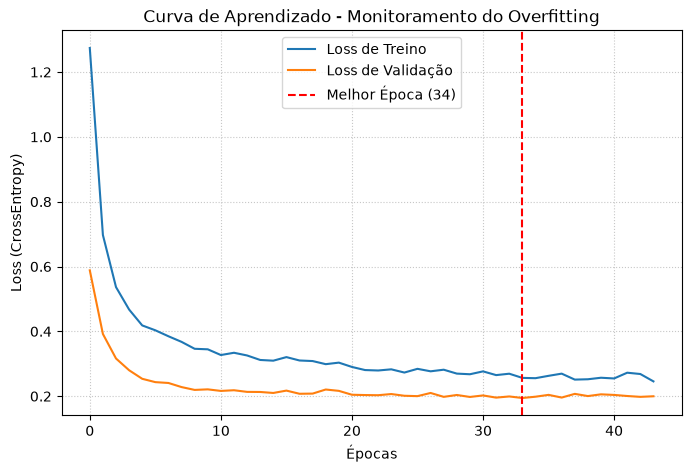

In [21]:
# 1. Plotando as curvas de aprendizado (Loss)
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Loss de Treino')
plt.plot(val_losses, label='Loss de Validação')

# Marca a linha de onde o melhor modelo foi salvo
melhor_epoca = len(train_losses) - patience_counter
plt.axvline(x=melhor_epoca - 1, color='r', linestyle='--', label=f'Melhor Época ({melhor_epoca})')

plt.title('Curva de Aprendizado - Monitoramento do Overfitting')
plt.xlabel('Épocas')
plt.ylabel('Loss (CrossEntropy)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

RELATÓRIO DE CLASSIFICAÇÃO (CONJUNTO DE TESTE):

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.94      0.93       160
      BOMBAY       1.00      1.00      1.00        62
        CALI       0.97      0.92      0.95       196
    DERMASON       0.92      0.91      0.92       428
       HOROZ       0.93      0.97      0.95       228
       SEKER       0.95      0.94      0.94       242
        SIRA       0.87      0.89      0.88       318

    accuracy                           0.93      1634
   macro avg       0.94      0.94      0.94      1634
weighted avg       0.93      0.93      0.93      1634



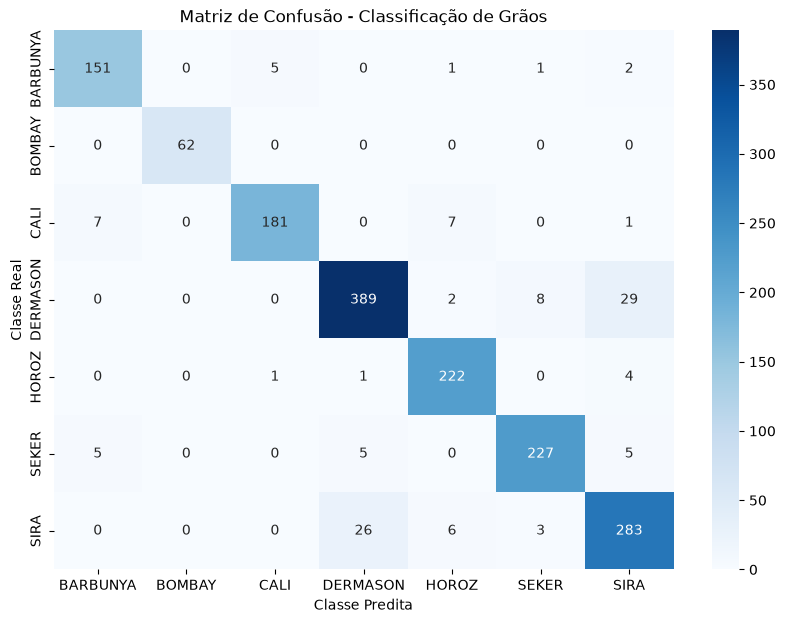

In [22]:
# 2. Avaliação final no conjunto de Teste
model.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    outputs = model(X_test_device)
    _, predicted = torch.max(outputs, 1)
    
    y_pred = predicted.cpu().numpy()
    y_true = y_test_tensor.numpy()

# 3. Relatório de Métricas
target_names = label_encoder.classes_
print("RELATÓRIO DE CLASSIFICAÇÃO (CONJUNTO DE TESTE):\n")
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusão - Classificação de Grãos')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.show()

## 5. Conclusão e Análise dos Resultados

A avaliação no conjunto de Teste revelou um desempenho altamente satisfatório do modelo, validando as técnicas de estabilidade e regularização adotadas:

1. **Curva de Aprendizado e Convergência:** O gráfico de perdas demonstra que a validação acompanhou de perto o treino. O *Early Stopping* evitou o *overfitting*, interrompendo o treinamento na época 44 e garantindo a capacidade de generalização. Não houve instabilidades severas (picos nos gráficos), provando a eficácia do `Batch Normalization` e da normalização das entradas.
2. **Eficiência no Desbalanceamento:** Apesar do severo desbalanceamento inicial, o modelo obteve um **Macro F1-Score de 0.94**, com a classe minoritária ('Bombay') alcançando 100% de precisão e revocação. Isso prova o sucesso da aplicação de pesos corretivos na função de custo (`CrossEntropyLoss`).
3. **Análise da Matriz de Confusão:** A matriz revela que os raros erros do modelo concentram-se em classes morfologicamente muito similares. O maior índice de erro ocorreu entre 'Sira' e 'Dermason' (26 instâncias de 'Sira' classificadas como 'Dermason', e 29 instâncias de 'Dermason' classificadas como 'Sira'). Isso sugere uma sobreposição natural dessas sementes no espaço de características (tamanho, formato e área).

O modelo apresenta alta robustez, baixo viés em relação às classes majoritárias e excelente capacidade preditiva.